In [1]:
import numpy as np
import matplotlib.pyplot as plt
import operator

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

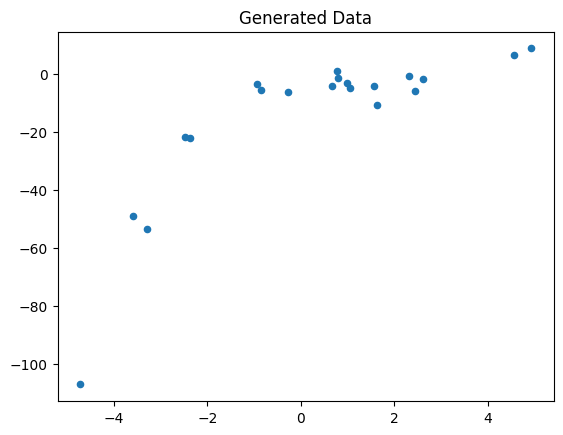

In [2]:
# -----------------------------
# Generate Dataset
# -----------------------------
np.random.seed(0)

X = 2 - 3 * np.random.normal(0, 1, 20)
Y = X - 2 * (X ** 2) + 0.5 * (X ** 3) + np.random.normal(-3, 3, 20)

plt.scatter(X, Y, s=20)
plt.title("Generated Data")
plt.show()

In [3]:
# -----------------------------
# Reshape Data
# -----------------------------
X = X.reshape(-1, 1)
Y = Y.reshape(-1, 1)

In [4]:
# -----------------------------
# Polynomial Features
# -----------------------------
degree = 15
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
# -----------------------------
# Overall Metrics
# -----------------------------
Y_pred = model.predict(X_poly)

print("OVERALL METRICS")
print("R2   :", r2_score(Y, Y_pred))
print("MSE  :", mean_squared_error(Y, Y_pred))
print("RMSE :", np.sqrt(mean_squared_error(Y, Y_pred)))
print("MAE  :", mean_absolute_error(Y, Y_pred))

OVERALL METRICS
R2   : 0.9970642753008947
MSE  : 2.0561828249967085
RMSE : 1.4339396169283798
MAE  : 0.7743176826246575


In [6]:
# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model.fit(X_train_poly, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# -----------------------------
# Train & Test Predictions
# -----------------------------
Y_train_pred = model.predict(X_train_poly)
Y_test_pred = model.predict(X_test_poly)

In [8]:
# -----------------------------
# Train-Test Metrics
# -----------------------------
train_r2 = r2_score(Y_train, Y_train_pred)
train_mse = mean_squared_error(Y_train, Y_train_pred)
train_mae = mean_absolute_error(Y_train, Y_train_pred)

test_r2 = r2_score(Y_test, Y_test_pred)
test_mse = mean_squared_error(Y_test, Y_test_pred)
test_mae = mean_absolute_error(Y_test, Y_test_pred)

print("POLYNOMIAL REGRESSION PERFORMANCE\n")
print("TRAIN DATA")
print(f"R2  : {train_r2:.4f}")
print(f"MSE : {train_mse:.4f}")
print(f"MAE : {train_mae:.4f}")

print("\nTEST DATA")
print(f"R2  : {test_r2:.4f}")
print(f"MSE : {test_mse:.4f}")
print(f"MAE : {test_mae:.4f}")

POLYNOMIAL REGRESSION PERFORMANCE

TRAIN DATA
R2  : 1.0000
MSE : 0.0000
MAE : 0.0003

TEST DATA
R2  : -2581416.0058
MSE : 1286577742.6409
MAE : 18086.9562


In [9]:
# -----------------------------
# Model Diagnosis
# -----------------------------
r2_gap = train_r2 - test_r2

print("\nMODEL DIAGNOSIS")
if train_r2 < 0.6 and test_r2 < 0.6:
    print("→ UNDERFITTING")
    print("Reason: Model too simple.")
elif train_r2 > 0.9 and r2_gap > 0.2:
    print("→ OVERFITTING")
    print("Reason: High-degree polynomial fits noise.")
else:
    print("→ GOOD FIT")
    print("Reason: Balanced train-test performance.")


MODEL DIAGNOSIS
→ OVERFITTING
Reason: High-degree polynomial fits noise.


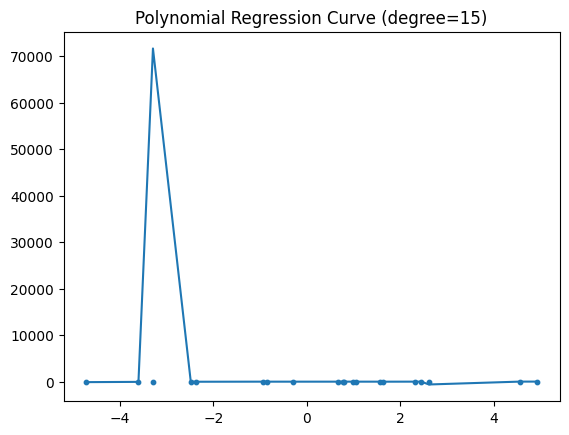

In [10]:
# -----------------------------
# Plot Polynomial Curve
# -----------------------------
X_sorted = np.sort(X, axis=0)
X_sorted_poly = poly.transform(X_sorted)
Y_curve = model.predict(X_sorted_poly)

plt.scatter(X, Y, s=10)
plt.plot(X_sorted, Y_curve)
plt.title(f"Polynomial Regression Curve (degree={degree})")
plt.show()